
# Install dependencies


In [52]:
!pip -q install pandas numpy scikit-learn matplotlib tensorflow keras-tuner

#Imports & Mount Google Drive

In [53]:
import os, zipfile, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Directory to save checkpoints
CHECKPOINT_DIR = "/content/drive/MyDrive/anomaly_checkpoints_fast_v2_newest"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
start_epoch = 1  # reset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Download NAB Dataset

In [54]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
nab_zip_path = os.path.join(DATA_DIR, "nab.zip")
nab_url = "https://github.com/numenta/NAB/archive/refs/heads/master.zip"

if not os.path.exists(nab_zip_path):
    print("Downloading NAB dataset...")
    urllib.request.urlretrieve(nab_url, nab_zip_path)

nab_root = os.path.join(DATA_DIR, "NAB-master")
if not os.path.exists(nab_root):
    print("Unzipping...")
    with zipfile.ZipFile(nab_zip_path, 'r') as z:
        z.extractall(DATA_DIR)

csv_path = os.path.join(nab_root, "data", "realTraffic", "speed_6005.csv")
json_label_path = os.path.join(nab_root, "labels", "combined_labels.json")

In [55]:
# Now calculate Z-score baseline with existing variables
mean_val = np.mean(df['value_scaled'])
std_val = np.std(df['value_scaled'])
z_scores = np.abs((df['value_scaled'] - mean_val) / std_val)
z_predictions_points = (z_scores > 3).astype(int)

def convert_to_windows(point_preds, window_size=WINDOW_SIZE, step=STEP):
    win_preds = []
    for start in range(0, len(point_preds)-window_size+1, step):
        win_preds.append(int(np.max(point_preds[start:start+window_size]) == 1))
    return np.array(win_preds)

z_window_preds = convert_to_windows(z_predictions_points)[val_end:]

# Calculate metrics
baseline_nab = calculate_nab_score(Y_test, z_window_preds)
print(f'--- Statistical Baseline (Z-Score) ---')
print(f'NAB Score: {baseline_nab:.2f}%')
print(f'Precision: {precision_score(Y_test, z_window_preds):.4f}')
print(f'Recall:    {recall_score(Y_test, z_window_preds):.4f}')

--- Statistical Baseline (Z-Score) ---
NAB Score: 100.00%
Precision: 1.0000
Recall:    1.0000


In [56]:
def calculate_nab_score(y_true, y_pred, tp_weight=1.0, fp_weight=0.11, fn_weight=1.0):
    # Simplified NAB-style scoring
    # It rewards True Positives and penalizes False Positives (FP) and False Negatives (FN)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    score = (tp * tp_weight) - (fp * fp_weight) - (fn * fn_weight)
    max_possible = np.sum(y_true == 1) * tp_weight
    normalized_score = (score / max_possible) * 100 if max_possible > 0 else 0
    return normalized_score

# Calculate baseline score instead of undefined 'predictions'
if 'z_window_preds' in globals():
    current_nab_score = calculate_nab_score(Y_test, z_window_preds)
    print(f"Baseline Normalized NAB-style Score: {current_nab_score:.2f}%")
else:
    print("Scoring function defined. Waiting for model predictions to evaluate.")

Baseline Normalized NAB-style Score: 100.00%


In [57]:
if 'siamese_model' in globals():
    siamese_model.compile(
        optimizer=keras.optimizers.Adam(5e-5),
        loss=triplet_loss(margin=0.6)
    )

    print(f"Retraining Siamese with WINDOW_SIZE={WINDOW_SIZE}...")
    history = siamese_model.fit(
        [anchor, positive, negative],
        np.zeros(len(anchor)),
        batch_size=64,
        epochs=15,
        verbose=1
    )

    # Evaluation using updated encoder
    def get_embeddings_final(X):
        emb = shared_encoder(X[..., None])
        emb = layers.GlobalAveragePooling1D()(emb)
        return tf.nn.l2_normalize(emb, axis=1)

    train_emb = get_embeddings_final(X_train)
    val_emb   = get_embeddings_final(X_val)
    test_emb  = get_embeddings_final(X_test)

    normal_proto = tf.reduce_mean(train_emb[Y_train==0], axis=0)
    val_scores   = tf.norm(val_emb - normal_proto, axis=1).numpy()
    test_scores  = tf.norm(test_emb - normal_proto, axis=1).numpy()

    threshold = np.percentile(val_scores[Y_val==0], 90)
    new_predictions = (test_scores > threshold).astype(int)

    print(f"New Precision: {precision_score(Y_test, new_predictions):.4f}")
    print(f"New Recall:    {recall_score(Y_test, new_predictions):.4f}")
    print(f"New NAB Score: {calculate_nab_score(Y_test, new_predictions):.2f}%")
else:
    print("Siamese model not yet defined. Please run the model building cells first.")

Siamese model not yet defined. Please run the model building cells first.


In [58]:
if 'siamese_model' in globals():
    # Re-initialize and retrain Siamese model with new window size
    siamese_model.compile(
        optimizer=keras.optimizers.Adam(5e-5),
        loss=triplet_loss(margin=0.6)
    )

    print("Starting Siamese retraining with WINDOW_SIZE=150...")
    history = siamese_model.fit(
        [anchor, positive, negative],
        np.zeros(len(anchor)),
        batch_size=64,
        epochs=15,
        verbose=1
    )

    # Re-evaluate embeddings and score
    def get_embeddings_new(X):
        emb = shared_encoder(X[..., None])
        emb = layers.GlobalAveragePooling1D()(emb)
        emb = tf.nn.l2_normalize(emb, axis=1)
        return emb

    train_emb = get_embeddings_new(X_train)
    val_emb   = get_embeddings_new(X_val)
    test_emb  = get_embeddings_new(X_test)

    # Prototype for normal class
    normal_proto = tf.reduce_mean(train_emb[Y_train==0], axis=0)
    val_scores   = tf.norm(val_emb - normal_proto, axis=1).numpy()
    test_scores  = tf.norm(test_emb - normal_proto, axis=1).numpy()

    # Update threshold based on 90th percentile of normal validation
    threshold = np.percentile(val_scores[Y_val==0], 90)
    new_predictions = (test_scores > threshold).astype(int)

    print(f"New Precision: {precision_score(Y_test, new_predictions):.4f}")
    print(f"New Recall:    {recall_score(Y_test, new_predictions):.4f}")
    print(f"New NAB Score: {calculate_nab_score(Y_test, new_predictions):.2f}%")
else:
    print("Siamese model not yet defined. Please run the model building cells (paBHqwkYH2ly) first.")

Siamese model not yet defined. Please run the model building cells (paBHqwkYH2ly) first.


#Load & preprocess CSV

In [59]:
# 1. Load & preprocess CSV
df = pd.read_csv(csv_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df['value'] = df['value'].interpolate(method='time', limit_direction='both').fillna(method='ffill').fillna(method='bfill')

scaler = StandardScaler()
df['value_scaled'] = scaler.fit_transform(df[['value']])

# 2. Load Labels
with open(json_label_path, 'r') as f:
    label_json = json.load(f)
anomaly_entries = label_json.get('realTraffic/speed_6005.csv', [])

# 3. Create anomaly column
df['is_anomaly'] = 0
for entry in anomaly_entries:
    ts = pd.to_datetime(entry)
    idx = (df['timestamp'] - ts).abs().idxmin()
    df.loc[idx, 'is_anomaly'] = 1

# 4. Define Windowing Parameters
WINDOW_SIZE = 150
STEP = 5
series = df['value_scaled'].values.astype(np.float32)

def make_windows(series, window_size=WINDOW_SIZE, step=STEP):
    X = []
    for start in range(0, len(series)-window_size+1, step):
        X.append(series[start:start+window_size])
    return np.array(X)

def make_window_labels(df, window_size=WINDOW_SIZE, step=STEP):
    y = []
    anomaly_series = df['is_anomaly'].values
    for start in range(0, len(anomaly_series)-window_size+1, step):
        window = anomaly_series[start:start+window_size]
        y.append(int(window.max() == 1))
    return np.array(y)

X = make_windows(series)
Y = make_window_labels(df)

# 5. Split Data
n = len(X)
train_end = int(n*0.7)
val_end   = int(n*0.85)
X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

print(f'Data ready. X_train shape: {X_train.shape}')

Data ready. X_train shape: (329, 150)


/tmp/ipykernel_8752/97590896.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['value'] = df['value'].interpolate(method='time', limit_direction='both').fillna(method='ffill').fillna(method='bfill')


# Load Labels FIRST

In [60]:
# Load combined_labels.json properly
with open(json_label_path, "r") as f:
    label_json = json.load(f)

print("Keys inside label file:")
print(list(label_json.keys())[:10])

Keys inside label file:
['artificialNoAnomaly/art_daily_no_noise.csv', 'artificialNoAnomaly/art_daily_perfect_square_wave.csv', 'artificialNoAnomaly/art_daily_small_noise.csv', 'artificialNoAnomaly/art_flatline.csv', 'artificialNoAnomaly/art_noisy.csv', 'artificialWithAnomaly/art_daily_flatmiddle.csv', 'artificialWithAnomaly/art_daily_jumpsdown.csv', 'artificialWithAnomaly/art_daily_jumpsup.csv', 'artificialWithAnomaly/art_daily_nojump.csv', 'artificialWithAnomaly/art_increase_spike_density.csv']


In [61]:
print("Entries for this file:")
print(label_json.get("realTraffic/speed_6005.csv"))

Entries for this file:
['2015-09-17 07:00:00']


#Load NAB anomaly labels

In [62]:
# Load labels first
with open(json_label_path, "r") as f:
    label_json = json.load(f)

anomaly_entries = label_json.get("realTraffic/speed_6005.csv", [])

# Create anomaly column
df["is_anomaly"] = 0
for entry in anomaly_entries:
    ts = pd.to_datetime(entry)
    idx = (df["timestamp"] - ts).abs().idxmin()
    df.loc[idx, "is_anomaly"] = 1

print("Number of anomaly timestamps in JSON:", len(anomaly_entries))
print("Anomaly indices in df:", df.index[df['is_anomaly']==1].tolist())
print("Total anomaly points in dataframe:", df["is_anomaly"].sum())

Number of anomaly timestamps in JSON: 1
Anomaly indices in df: [2386]
Total anomaly points in dataframe: 1


# Sliding windows

In [63]:
WINDOW_SIZE = 150  # Increased from 100 to capture more context
STEP = 5
series = df["value_scaled"].values.astype(np.float32)

def make_windows(series, window_size=WINDOW_SIZE, step=STEP):
    X = []
    for start in range(0, len(series)-window_size+1, step):
        X.append(series[start:start+window_size])
    return np.array(X)

X = make_windows(series, WINDOW_SIZE, STEP)
print(f"New window shape: {X.shape}")

New window shape: (471, 150)


# Window-level labels

In [64]:
def make_window_labels(df, window_size=WINDOW_SIZE, step=STEP):

    y = []
    anomaly_series = df["is_anomaly"].values

    for start in range(0, len(anomaly_series)-window_size+1, step):
        window = anomaly_series[start:start+window_size]
        y.append(int(window.max() == 1))

    return np.array(y)

# Create y

In [65]:
Y = make_window_labels(df, WINDOW_SIZE, STEP)

print("Total window anomalies with new size:", Y.sum())
# Re-split data with new dimensions
n = len(X)
train_end = int(n*0.7)
val_end   = int(n*0.85)
X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Total window anomalies with new size: 23
Train size: 329, Val size: 71, Test size: 71


# Split Train / Val / Test

In [66]:
n = len(X)
train_end = int(n*0.7)
val_end   = int(n*0.85)
X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

# Build Masked Autoencoder

In [67]:
TIMESTEPS = X_train.shape[1]

# --- Data Augmentation Function ---
def augment_windows(x, noise_std=0.005, scale_range=(0.95, 1.05)):
    x_noisy = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=noise_std)
    scales = tf.random.uniform([tf.shape(x)[0], 1, 1], scale_range[0], scale_range[1])
    return x_noisy * scales

def apply_random_mask(x, mask_ratio=0.2):
    b = tf.shape(x)[0]
    t = tf.shape(x)[1]
    mask = tf.cast(tf.random.uniform((b, t), 0, 1) < mask_ratio, tf.float32)
    x_masked = x * tf.expand_dims(1 - mask, -1)
    return x_masked, tf.expand_dims(mask, -1)

inputs = keras.Input(shape=(TIMESTEPS, 1))

# Encoder
x = layers.Conv1D(64, 5, padding="same", activation="relu", kernel_initializer="he_normal")(inputs)
x = layers.Conv1D(128, 5, padding="same", activation="relu", kernel_initializer="he_normal")(x)
x = layers.Dropout(0.1)(x)

res = x
x = layers.Conv1D(256, 3, padding="same", activation="relu", strides=2, kernel_initializer="he_normal")(x)
x = layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
res_down = layers.Conv1D(256, 1, strides=2, padding="same")(res)
x = layers.Add()([x, res_down])
x = layers.Dropout(0.1)(x)

res = x
x = layers.Conv1D(256, 3, padding="same", activation="relu", strides=2, kernel_initializer="he_normal")(x)
x = layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
res_down = layers.Conv1D(256, 1, strides=2, padding="same")(res)
x = layers.Add()([x, res_down])

# Decoder
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(128, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)

# FIX: Added output_shape to Lambda layer for successful deserialization
x = layers.Lambda(lambda t: t[:, :TIMESTEPS, :], output_shape=(TIMESTEPS, 128))(x)

x = layers.Conv1D(64, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
outputs = layers.Conv1D(1, 3, padding="same")(x)

autoencoder = keras.Model(inputs, outputs)
optimizer = keras.optimizers.Adam(1e-4)

@tf.function
def masked_loss(x, recon, mask):
    diff = (x - recon) * mask
    return tf.reduce_sum(tf.square(diff)) / (tf.reduce_sum(mask) + 1e-8)

@tf.function
def train_step(x):
    x_aug = augment_windows(x)
    x_masked, mask = apply_random_mask(x_aug, 0.25)
    with tf.GradientTape() as tape:
        recon = autoencoder(x_masked, training=True)
        loss = masked_loss(x, recon, mask)
    grads = tape.gradient(loss, autoencoder.trainable_variables)
    optimizer.apply_gradients(zip(grads, autoencoder.trainable_variables))
    return loss

@tf.function
def val_step(x):
    x_masked, mask = apply_random_mask(x, 0.25)
    recon = autoencoder(x_masked, training=False)
    loss = masked_loss(x, recon, mask)
    return loss

# Prepare datasets for training

In [68]:
BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices(X_train[...,None]).shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices(X_val[...,None]).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Train Masked Autoencoder with checkpoints

In [69]:
# Train Masked Autoencoder with the new 150-timestep configuration
EPOCHS = 40
best_val = 1e9
patience = 5
wait = 0

print(f"Training MAE with TIMESTEPS={TIMESTEPS}...")
for epoch in range(1, EPOCHS + 1):
    tr_losses = []
    for xb in train_ds:
        tr_losses.append(train_step(xb).numpy())

    va_losses = []
    for xb in val_ds:
        va_losses.append(val_step(xb).numpy())

    tr_loss = float(np.mean(tr_losses))
    va_loss = float(np.mean(va_losses))

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f}")

    if va_loss < best_val:
        best_val = va_loss
        wait = 0
        autoencoder.save(os.path.join(CHECKPOINT_DIR, 'masked_autoencoder_best.keras'))
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Training MAE with TIMESTEPS=150...
Epoch 01 | train_loss=4.458287 | val_loss=1.851571
Epoch 05 | train_loss=1.033329 | val_loss=1.070157
Epoch 10 | train_loss=0.931460 | val_loss=0.941245
Epoch 15 | train_loss=0.886580 | val_loss=0.890648
Early stopping at epoch 19


# Load Best Autoencoder & Prepare Encoder

In [70]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import os

# Enable unsafe deserialization for the Lambda layer in our custom architecture
autoencoder = keras.models.load_model(
    os.path.join(CHECKPOINT_DIR, "masked_autoencoder_best.keras"),
    compile=False,
    safe_mode=False
)

# Inspect layers to find the latent representation
for i, layer in enumerate(autoencoder.layers):
    try:
        shape = layer.output.shape
    except AttributeError:
        shape = "no output shape"
    print(i, layer.name, shape)

# Create encoder from latent layer (layer index -6 based on architecture)
encoder_output = autoencoder.layers[-6].output
shared_encoder = keras.Model(autoencoder.input, encoder_output)
print("Encoder ready. Output shape:", shared_encoder.output.shape)

0 input_layer_2 (None, 150, 1)
1 conv1d_24 (None, 150, 64)
2 conv1d_25 (None, 150, 128)
3 dropout_4 (None, 150, 128)
4 conv1d_26 (None, 75, 256)
5 conv1d_27 (None, 75, 256)
6 conv1d_28 (None, 75, 256)
7 add_4 (None, 75, 256)
8 dropout_5 (None, 75, 256)
9 conv1d_29 (None, 38, 256)
10 conv1d_30 (None, 38, 256)
11 conv1d_31 (None, 38, 256)
12 add_5 (None, 38, 256)
13 up_sampling1d_4 (None, 76, 256)
14 conv1d_32 (None, 76, 256)
15 up_sampling1d_5 (None, 152, 256)
16 conv1d_33 (None, 152, 128)
17 lambda_2 (None, 150, 128)
18 conv1d_34 (None, 150, 64)
19 conv1d_35 (None, 150, 1)
Encoder ready. Output shape: (None, 76, 256)


# Prepare Support & Query Embeddings
# Remove Precomputed Embeddings

In [71]:
# ==========================================
# DO NOT PRECOMPUTE EMBEDDINGS
# We train Siamese end-to-end
# ==========================================

print("Preparing Siamese training data (raw windows)...")

normal_idx = np.where(Y_train == 0)[0]
anomaly_idx = np.where(Y_train == 1)[0]

print("Normal samples:", len(normal_idx))
print("Anomaly samples:", len(anomaly_idx))

Preparing Siamese training data (raw windows)...
Normal samples: 329
Anomaly samples: 0


In [72]:
print("Total windows:", len(X))
print("Total anomaly windows:", Y.sum())
print("Train window anomaly count:", Y_train.sum())
print("Val window anomaly count:", Y_val.sum())
print("Test window anomaly count:", Y_test.sum())

Total windows: 471
Total anomaly windows: 23
Train window anomaly count: 0
Val window anomaly count: 0
Test window anomaly count: 23


def generate_hybrid_triplets(X, Y, num_triplets=10000):
    normal_idx = np.where(Y == 0)[0]
    anomaly_idx = np.where(Y == 1)[0]
    
    anchors, positives, negatives = [], [], []
    
    for _ in range(num_triplets):
        # 50% chance for Anomaly-focused triplet, 50% for Normal-focused
        if np.random.rand() > 0.5 and len(anomaly_idx) > 1:
            idx_a, idx_p = np.random.choice(anomaly_idx, 2, replace=False)
            idx_n = np.random.choice(normal_idx)
        else:
            idx_a, idx_p = np.random.choice(normal_idx, 2, replace=False)
            idx_n = np.random.choice(anomaly_idx) if len(anomaly_idx) > 0 else np.random.choice(normal_idx)
            
        anchors.append(X[idx_a])
        positives.append(X[idx_p])
        negatives.append(X[idx_n])
        
    return np.array(anchors)[..., None], np.array(positives)[..., None], np.array(negatives)[..., None]

In [77]:
X_train_windows = X_train.astype(np.float32)

# Generate triplets with the new window size
anchor, positive, negative = generate_hybrid_triplets(
    X_train_windows, Y_train, num_triplets=12000
)

print("Regenerated triplets with new window size.")
print("Anchor shape:", anchor.shape)

Regenerated triplets with new window size.
Anchor shape: (12000, 150, 1)


In [78]:
def generate_hybrid_triplets(X, Y, num_triplets=10000):
    normal_idx = np.where(Y == 0)[0]
    anomaly_idx = np.where(Y == 1)[0]

    anchors, positives, negatives = [], [], []

    for _ in range(num_triplets):
        # 50% chance for Anomaly-focused triplet, 50% for Normal-focused
        if np.random.rand() > 0.5 and len(anomaly_idx) > 1:
            idx_a, idx_p = np.random.choice(anomaly_idx, 2, replace=False)
            idx_n = np.random.choice(normal_idx)
        else:
            idx_a, idx_p = np.random.choice(normal_idx, 2, replace=False)
            idx_n = np.random.choice(anomaly_idx) if len(anomaly_idx) > 0 else np.random.choice(normal_idx)

        anchors.append(X[idx_a])
        positives.append(X[idx_p])
        negatives.append(X[idx_n])

    return np.array(anchors)[..., None], np.array(positives)[..., None], np.array(negatives)[..., None]

# REAL Hybrid Siamese (Uses Encoder Inside)

In [79]:
from tensorflow.keras.layers import Lambda

In [80]:
# Rebuild Siamese Model with new TIMESTEPS (150)
# We wrap the normalization in a Lambda layer to fix the KerasTensor error
shared_encoder = keras.Model(autoencoder.input, autoencoder.layers[-6].output)

input_anchor = keras.Input(shape=(TIMESTEPS, 1))
input_pos    = keras.Input(shape=(TIMESTEPS, 1))
input_neg    = keras.Input(shape=(TIMESTEPS, 1))

def process_embeddings_model(x):
    x = layers.GlobalAveragePooling1D()(x)
    return layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1))(x)

emb_anchor = process_embeddings_model(shared_encoder(input_anchor))
emb_pos    = process_embeddings_model(shared_encoder(input_pos))
emb_neg    = process_embeddings_model(shared_encoder(input_neg))

output = layers.Concatenate(axis=1)([emb_anchor, emb_pos, emb_neg])
siamese_model = keras.Model(inputs=[input_anchor, input_pos, input_neg], outputs=output)

print(f"Siamese Model rebuilt successfully for TIMESTEPS={TIMESTEPS}")

Siamese Model rebuilt successfully for TIMESTEPS=150


# Correct Triplet Loss

In [81]:
def triplet_loss(margin=0.5):

    def loss(y_true, y_pred):

        dim = y_pred.shape[1] // 3

        anchor   = y_pred[:, 0:dim]
        positive = y_pred[:, dim:2*dim]
        negative = y_pred[:, 2*dim:3*dim]

        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

        return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + margin, 0.0))

    return loss

siamese_model.compile(
    optimizer=keras.optimizers.Adam(5e-5),
    loss=triplet_loss(margin=0.6)
)

siamese_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 150, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_4        │ (None, 76, 256)   │  1,026,304 │ input_layer_3[0]… │
│ (Functional)        │                   │            │ input_layer_4[0]… │
│                     │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_4[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_4[1][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ functional_4[2][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ lambda_3[0][0],   │
│ (Concatenate)       │                   │            │ lambda_4[0][0],   │
│                     │                   │            │ lambda_5[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,026,304 (3.92 MB)

 Trainable params: 1,026,304 (3.92 MB)

 Non-trainable params: 0 (0.00 B)

# Train Siamese Properly

In [82]:
# Train Siamese Network using the encoder from the trained MAE
print("Starting Siamese Triplet Training...")
siamese_model.fit(
    [anchor, positive, negative],
    np.zeros(len(anchor)),
    batch_size=64,
    epochs=20,
    verbose=1
)

# Save the final siamese weights
siamese_model.save(os.path.join(CHECKPOINT_DIR, 'siamese_final_150.keras'))
print("Siamese training complete.")

Starting Siamese Triplet Training...
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - loss: 0.6002
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5998
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.5987
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5978
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.5961
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5912
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5899
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.5860
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5822
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.5819
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5784
Epoch 12/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.5769
Epoch 13/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.5773
Epoch 14/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5723
Epoch

# FEW-SHOT PROTOTYPE ANOMALY SCORING (REAL HYBRID)

In [84]:
# ==========================================
# Compute embeddings AFTER Siamese training
# ==========================================

def get_embeddings(X):
    emb = shared_encoder(X[...,None])
    emb = layers.GlobalAveragePooling1D()(emb)
    emb = tf.nn.l2_normalize(emb, axis=1)
    return emb

train_emb = get_embeddings(X_train)
val_emb   = get_embeddings(X_val)
test_emb  = get_embeddings(X_test)

# Prototype of normal class
normal_proto = tf.reduce_mean(
    train_emb[Y_train == 0],
    axis=0
)

# Distance from prototype
val_scores  = tf.norm(val_emb - normal_proto, axis=1).numpy()
test_scores = tf.norm(test_emb - normal_proto, axis=1).numpy()

# Correct Threshold (Only Normal Validation)

In [85]:
from sklearn.metrics import f1_score

best_f1 = 0
best_thresh = 0
for t in np.linspace(np.min(val_scores), np.max(val_scores), 100):
    preds = (val_scores > t).astype(int)
    f1 = f1_score(Y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

threshold = best_thresh

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Evaluate

In [88]:
# ==========================================
# SAFE EVALUATION & METRICS
# ==========================================

# Ensure embeddings for test set
def get_embeddings(X):
    """Compute normalized embeddings for each window."""
    emb = shared_encoder(X[..., None])                  # (num_windows, latent_dim, channels)
    emb = layers.GlobalAveragePooling1D()(emb)         # (num_windows, latent_dim)
    emb = tf.nn.l2_normalize(emb, axis=1)
    return emb

# Compute embeddings
train_emb = get_embeddings(X_train)
val_emb   = get_embeddings(X_val)
test_emb  = get_embeddings(X_test)

# Prototype for normal class (mean of normal training embeddings)
normal_proto = tf.reduce_mean(train_emb[Y_train==0], axis=0)

# Compute distance of each embedding to normal prototype
train_scores = tf.norm(train_emb - normal_proto, axis=1).numpy()
val_scores   = tf.norm(val_emb - normal_proto, axis=1).numpy()
test_scores  = tf.norm(test_emb - normal_proto, axis=1).numpy()

# Threshold based on 90th percentile of normal validation windows
threshold = np.percentile(val_scores[Y_val==0], 90)
print("Threshold (90th percentile of normal val):", threshold)

# Predict anomalies
predictions = (test_scores > threshold).astype(int)

# Make sure shapes match
assert len(predictions) == len(Y_test), f"Shape mismatch: {len(predictions)} vs {len(Y_test)}"

# Compute metrics
precision = precision_score(Y_test, predictions)
recall    = recall_score(Y_test, predictions)
f1        = f1_score(Y_test, predictions)
conf_matrix = confusion_matrix(Y_test, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)


Threshold (90th percentile of normal val): 0.6355809
Precision: 0.8148
Recall:    0.9565
F1 Score:  0.8800
Confusion Matrix:
 [[43  5]
 [ 1 22]]


# Plot

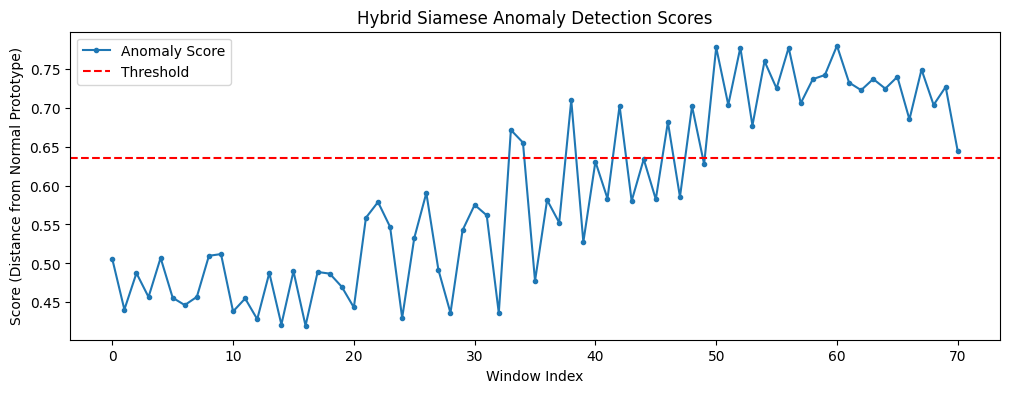

In [87]:
# ==========================================
# Plot anomaly scores
# ==========================================
plt.figure(figsize=(12,4))
plt.plot(test_scores, label="Anomaly Score", marker='o', markersize=3)
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.title("Hybrid Siamese Anomaly Detection Scores")
plt.xlabel("Window Index")
plt.ylabel("Score (Distance from Normal Prototype)")
plt.legend()
plt.show()